In [1]:
import numpy as np
import pandas as pd
import datetime as dt

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import xgboost as xgb

# In Kaggle notebooks, %matplotlib inline is used; in .py execution it would error.
# Fix: use a safe backend-agnostic call.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# Fix: use the provided Kaggle paths in this environment.
# Prefer /kaggle/input; fall back to relative ../input if present.
import os

BASE_INPUT = "/kaggle/input"
if not os.path.exists(BASE_INPUT):
    BASE_INPUT = "../input"

TRAIN_PATH = os.path.join(BASE_INPUT, "train.csv")
TEST_PATH = os.path.join(BASE_INPUT, "test.csv")

# Keep core logic (small sample of train)
train = pd.read_csv(TRAIN_PATH, nrows=10000)
test = pd.read_csv(TEST_PATH)

train.dtypes



key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [2]:
print("Sum of NaN values for each column")
print(train.isnull().sum())

train = train.dropna()
print("Sum of NaN values for each column after dropping NaN")
print(train.isnull().sum())



Sum of NaN values for each column
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64
Sum of NaN values for each column after dropping NaN
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


In [3]:
train.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.235464,-72.466660,39.920448,-72.474094,39.893281,1.644700
std,9.584258,10.609729,7.318932,10.579732,6.339919,1.271229
min,-2.900000,-74.438233,-74.006893,-74.429332,-73.994392,0.000000
25%,6.000000,-73.992058,40.734547,-73.991112,40.735230,1.000000
50%,8.500000,-73.981758,40.752693,-73.980083,40.753738,1.000000
75%,12.500000,-73.966925,40.767694,-73.963504,40.768186,2.000000
max,180.000000,40.766125,401.083332,40.802437,41.366138,6.000000


In [4]:
train = train.loc[(train["fare_amount"] > 0) & (train["fare_amount"] < 200)]
train = train.loc[
    (train["pickup_longitude"] > -300) & (train["pickup_longitude"] < 300)
]
train = train.loc[(train["pickup_latitude"] > -300) & (train["pickup_latitude"] < 300)]
train = train.loc[
    (train["dropoff_longitude"] > -300) & (train["dropoff_longitude"] < 300)
]
train = train.loc[
    (train["dropoff_latitude"] > -300) & (train["dropoff_latitude"] < 300)
]
train = train.loc[train["passenger_count"] <= 8]
train.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,11.239046,-72.466227,39.884169,-72.473662,39.893035,1.644893
std,9.583340,10.611292,6.366501,10.581290,6.340854,1.271371
min,0.010000,-74.438233,-74.006893,-74.429332,-73.994392,0.000000
25%,6.000000,-73.992057,40.734562,-73.991112,40.735233,1.000000
50%,8.500000,-73.981762,40.752694,-73.980087,40.753740,1.000000
75%,12.500000,-73.966957,40.767693,-73.963527,40.768185,2.000000
max,180.000000,40.766125,41.366138,40.802437,41.366138,6.000000


In [5]:
print("Sum of NaN values for each column")
print(test.isnull().sum())



Sum of NaN values for each column
key                  0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


In [6]:
# Fix: pandas removed .dt.week/.dt.weekofyear; use ISO calendar week.
# Keep same feature intent (week number).
combine = [test, train]
for dataset in combine:
    dataset["longitude_distance"] = (
        dataset["pickup_longitude"] - dataset["dropoff_longitude"]
    )
    dataset["latitude_distance"] = (
        dataset["pickup_latitude"] - dataset["dropoff_latitude"]
    )

    dataset["distance_travelled"] = (
        dataset["longitude_distance"] ** 2 + dataset["latitude_distance"] ** 2
    ) ** 0.5
    dataset["distance_travelled_sin"] = np.sin(
        (dataset["longitude_distance"] ** 2 * dataset["latitude_distance"] ** 2) ** 0.5
    )
    dataset["distance_travelled_cos"] = np.cos(
        (dataset["longitude_distance"] ** 2 * dataset["latitude_distance"] ** 2) ** 0.5
    )
    dataset["distance_travelled_sin_sqrd"] = (
        np.sin(
            (dataset["longitude_distance"] ** 2 * dataset["latitude_distance"] ** 2)
            ** 0.5
        )
        ** 2
    )
    dataset["distance_travelled_cos_sqrd"] = (
        np.cos(
            (dataset["longitude_distance"] ** 2 * dataset["latitude_distance"] ** 2)
            ** 0.5
        )
        ** 2
    )

    R = 6371e3  # Metres
    phi1 = np.radians(dataset["pickup_latitude"])
    phi2 = np.radians(dataset["dropoff_latitude"])
    phi_chg = np.radians(dataset["pickup_latitude"] - dataset["dropoff_latitude"])
    delta_chg = np.radians(dataset["pickup_longitude"] - dataset["dropoff_longitude"])

    # Note: original formula appears non-standard; keep core logic as-is to preserve semantics.
    a = (
        np.sin(phi_chg / 2) ** 0.5
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_chg / 2) ** 0.5
    )
    c = 2 * np.arctan2(a**0.5, (1 - a) ** 0.5)
    d = R * c
    dataset["haversine"] = d

    y = np.sin(delta_chg * np.cos(phi2))
    x = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(delta_chg)
    dataset["bearing"] = np.arctan2(y, x)

    dataset["pickup_datetime"] = pd.to_datetime(
        dataset["pickup_datetime"], errors="coerce"
    )
    dataset["hour_of_day"] = dataset.pickup_datetime.dt.hour
    dataset["day"] = dataset.pickup_datetime.dt.day
    # ISO week extraction (int), matching legacy "week of year" intent
    iso = dataset["pickup_datetime"].dt.isocalendar()
    dataset["week"] = iso.week.astype("int16")
    dataset["month"] = dataset.pickup_datetime.dt.month
    dataset["day_of_year"] = dataset.pickup_datetime.dt.dayofyear
    dataset["week_of_year"] = iso.week.astype("int16")

train = train.loc[train["haversine"] != 0]
train = train.dropna()

train.head()



,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,longitude_distance,latitude_distance,...,distance_travelled_sin_sqrd,distance_travelled_cos_sqrd,haversine,bearing,hour_of_day,day,week,month,day_of_year,week_of_year
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,0.008504,0.010708,...,8.292075e-09,1.000000,1.543912e+06,2.599961,0,18,33,8,230,33
7,2012-01-04 17:22:00.00000081,16.5,2012-01-04 17:22:00+00:00,-73.951300,40.774138,-73.990095,40.751048,1,0.038795,0.023090,...,8.024154e-07,0.999999,2.012980e+06,2.236596,17,4,1,1,4,1
13,2013-07-02 19:54:00.000000232,7.0,2013-07-02 19:54:00+00:00,-74.005360,40.728867,-74.008913,40.710907,1,0.003553,0.017960,...,4.071956e-09,1.000000,1.601686e+06,2.992745,19,2,27,7,183,27
16,2014-02-19 07:22:00.00000074,12.5,2014-02-19 07:22:00+00:00,-73.986430,40.760465,-73.988990,40.737075,1,0.002560,0.023390,...,3.585423e-09,1.000000,1.666078e+06,3.058851,7,19,8,2,50,8
17,2009-07-22 16:08:00.000000163,5.3,2009-07-22 16:08:00+00:00,-73.981060,40.737690,-73.994177,40.728412,1,0.013117,0.009278,...,1.481077e-08,1.000000,1.571892e+06,2.321711,16,22,30,7,203,30


In [7]:
print("Train data: Sum of NaN values for each column")
print(train.isnull().sum())
print("Test data: Sum of NaN values for each column")
print(test.isnull().sum())



Train data: Sum of NaN values for each column
key                            0
fare_amount                    0
pickup_datetime                0
pickup_longitude               0
pickup_latitude                0
dropoff_longitude              0
dropoff_latitude               0
passenger_count                0
longitude_distance             0
latitude_distance              0
distance_travelled             0
distance_travelled_sin         0
distance_travelled_cos         0
distance_travelled_sin_sqrd    0
distance_travelled_cos_sqrd    0
haversine                      0
bearing                        0
hour_of_day                    0
day                            0
week                           0
month                          0
day_of_year                    0
week_of_year                   0
dtype: int64
Test data: Sum of NaN values for each column
key                               0
pickup_datetime                   0
pickup_longitude                  0
pickup_latitude              

In [8]:
median = test["haversine"].median()
test["haversine"] = test["haversine"].fillna(median)



<Axes: title={'center': 'Pearson Correlation of Features'}>

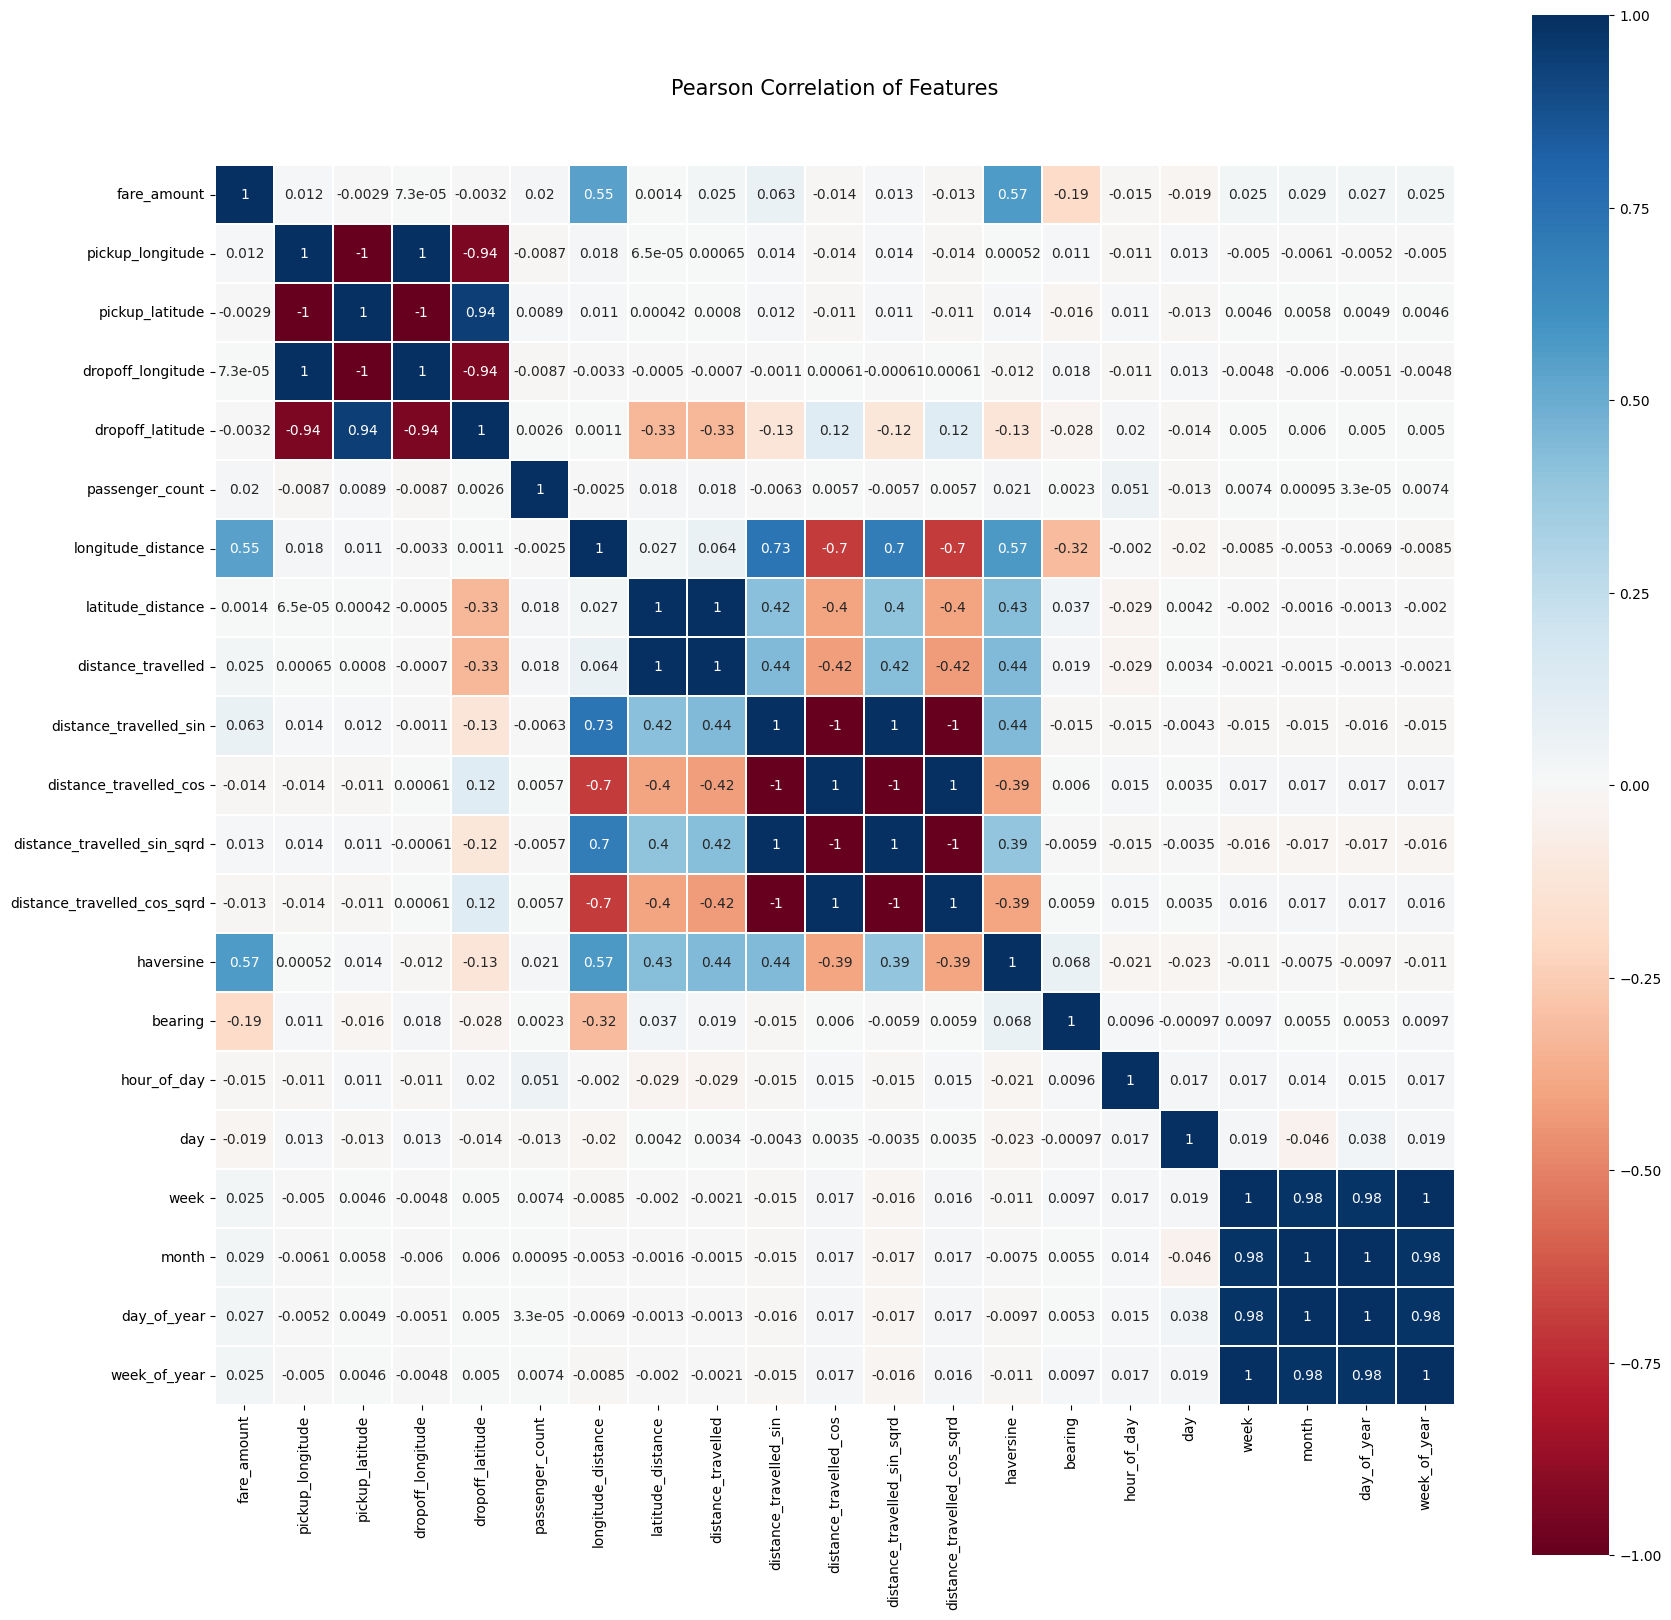

In [9]:
# Fix: correlation requires numeric_only with mixed dtypes; this is exploratory and score-neutral.
colormap = plt.cm.RdBu
plt.figure(figsize=(20, 20))
plt.title("Pearson Correlation of Features", y=1.05, size=15)
sns.heatmap(
    train.corr(numeric_only=True),
    linewidths=0.1,
    vmax=1.0,
    square=True,
    cmap=colormap,
    linecolor="white",
    annot=True,
)



In [10]:
# Fix: pandas drop signature changed; use keyword axis.
train_features_to_keep = ["haversine", "fare_amount"]
train.drop(columns=train.columns.difference(train_features_to_keep), inplace=True)

test_features_to_keep = ["haversine", "key"]
test.drop(columns=test.columns.difference(test_features_to_keep), inplace=True)



In [11]:
x_train = train.drop("fare_amount", axis=1)
y_train = train["fare_amount"]
x_test = test.drop("key", axis=1)

from sklearn.linear_model import LinearRegression

regr = LinearRegression()
regr.fit(x_train, y_train)
regr_pred = regr.predict(x_test)

from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(random_state=123)
rfr.fit(x_train, y_train)
rfr_pred = rfr.predict(x_test)



In [12]:
# Keep core logic: XGBoost trained on the same engineered/selected features.
x_pred = test.drop("key", axis=1)

# Use a fresh split without mutating original 'train' in-place to avoid accidental column loss.
X = train.drop("fare_amount", axis=1)
y = train["fare_amount"]
x_train, x_valid, y_train, y_valid = train_test_split(
    X, y, random_state=123, test_size=0.2
)


def XGBmodel(x_train, x_test, y_train, y_test):
    matrix_train = xgb.DMatrix(x_train, label=y_train)
    matrix_test = xgb.DMatrix(x_test, label=y_test)
    # Fix: reg:linear is deprecated; use reg:squarederror with same RMSE evaluation.
    model = xgb.train(
        params={"objective": "reg:squarederror", "eval_metric": "rmse", "seed": 123},
        dtrain=matrix_train,
        num_boost_round=200,
        early_stopping_rounds=20,
        evals=[(matrix_test, "test")],
        verbose_eval=False,
    )
    return model


model = XGBmodel(x_train, x_valid, y_train, y_valid)
xgb_pred = model.predict(
    xgb.DMatrix(x_pred), iteration_range=(0, model.best_iteration + 1)
)



In [13]:
regr_pred, rfr_pred, xgb_pred



(array([ 9.68856643, 10.22181898,  6.54765009, ...,  7.45278016,
        12.0523254 ,  5.81199121]),
 array([7.003, 6.784, 6.386, ..., 6.004, 9.584, 4.968]),
 array([ 8.069139,  8.252081,  6.263182, ...,  6.493344, 10.031241,
         5.757641], dtype=float32))

In [14]:
regr_weight = 1
rfr_weight = 1
xgb_weight = 3
prediction = (
    regr_pred * regr_weight + rfr_pred * rfr_weight + xgb_pred * xgb_weight
) / (regr_weight + rfr_weight + xgb_weight)



In [15]:
prediction



array([ 8.17979659,  8.35241235,  6.34463941, ...,  6.58736243,
       10.34600974,  5.61058275])

In [16]:
submission = pd.DataFrame({"key": test["key"], "fare_amount": np.round(prediction, 2)})

# Ensure csv suffix and correct columns
submission.to_csv("sub_fare.csv", index=False)



In [17]:
submission

,key,fare_amount
0,2010-10-01 21:26:11.0000001,8.18
1,2013-10-06 01:38:00.00000083,8.35
2,2012-03-30 19:13:53.0000001,6.34
3,2012-02-08 02:57:23.0000001,8.35
4,2013-12-13 22:56:00.000000237,8.35
...,...,...
9909,2010-12-02 01:44:39.0000002,8.35
9910,2010-06-07 16:17:38.0000003,22.81
9911,2013-11-01 08:37:36.0000003,6.59
9912,2011-05-03 10:14:00.000000123,10.35
